# Data Driven Analytics Summative 2: Technical Implementation

“To what extent can customer-level behavioural and transactional features be used to predict churn risk, and which factors contribute most significantly to customer attrition?”

## Data Acquisition and Engineering

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ulrikthygepedersen/online-retail-dataset",
    "online_retail.csv",
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Missing Values

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Missing Stock Codes

In [5]:
df.shape

(541909, 8)

In [6]:
# Count unique descriptions per StockCode
desc_counts = df.groupby("StockCode")["Description"].nunique()

# StockCodes with more than one description
multi_desc_stockcodes = desc_counts[desc_counts > 1]

# Inspect
multi_desc_stockcodes.sort_values(ascending=False).head(10)


StockCode
20713     8
23084     7
85175     6
21830     6
85172     5
21181     5
72807A    5
23131     5
23343     5
85123A    4
Name: Description, dtype: int64

In [7]:
# StockCodes with missing descriptions
missing_desc_stockcodes = df.loc[
    df["Description"].isnull(), "StockCode"
].unique()

ambiguous_stockcodes = multi_desc_stockcodes.index.intersection(
    missing_desc_stockcodes
)

print(f"Number of ambiguous StockCodes: {len(ambiguous_stockcodes)}")

Number of ambiguous StockCodes: 174


In [8]:
df[df["StockCode"].isin(ambiguous_stockcodes)][
    ["StockCode", "Description"]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description
103332,10080,GROOVY CACTUS INFLATABLE
454350,10080,check
279310,10080,NaN
23437,15058A,BLUE POLKADOT GARDEN PARASOL
192289,15058A,wet/rusty
...,...,...
10792,90014B,GOLD M PEARL ORBIT NECKLACE
386649,90014B,GOLD M.O.P. ORBIT NECKLACE
142063,90014C,SILVER/BLACK ORBIT NECKLACE
381682,90014C,NaN


Stock Code is complete, description is not. Null values will be filled with the appropriate description based on stock code. In stock codes where more than one description is present, the most common description is used.

In [9]:
# Create a mapping from StockCode to the most common non-null Description
stockcode_description_map = (
    df.dropna(subset=["Description"])
      .groupby("StockCode")["Description"]
      .agg(lambda x: x.mode().iloc[0])
)

df["Description"] = df["Description"].fillna(
    df["StockCode"].map(stockcode_description_map)
)

df["Description"].isnull().sum()

112

Records where no historical description existed for the StockCode were retained but flagged to preserve transaction integrity

In [10]:
df["Description"] = df["Description"].fillna("UNKNOWN_PRODUCT")
df["Description"].isnull().sum()

0

In [11]:
df.shape

(541909, 8)

An exploratory consistency check revealed that a small subset of StockCodes mapped to multiple product descriptions, indicating historical inconsistency in the source data.
For StockCodes with missing descriptions, the most frequently occurring description was used to minimise semantic ambiguity.
StockCodes with no historical descriptions were retained and flagged as unknown to preserve transactional integrity.

#### Missing CustomerID

There are 135080 missing customerID rows. It is not feasible to simply drop these rows without losing large amounts of information, inputting random values would destroy the churn analysis and using mean values would not make sense. Because CustomerID is assigned at the invoicelevel and each invoice can span multiple rows, we can attempt to recover missing CustomerIDs by looking at other rows with the same InvoiceNo.

In [12]:
# Build a mapping: InvoiceNo → CustomerID
invoice_customer_map = (
    df.dropna(subset=["CustomerID"])
      .groupby("InvoiceNo")["CustomerID"]
      .agg(lambda x: x.mode().iloc[0])
)

df["CustomerID"] = df["CustomerID"].fillna(
    df["InvoiceNo"].map(invoice_customer_map)
)

df["CustomerID"].isnull().sum()

135080

You attempted recovery using key‑based logic
You validated whether recovery was possible
You concluded (correctly) that it was not feasible without inventing data. 

To preserve the data, these rows will be kept. It was considered to fill these rows with "Guest User" however this would impact the datatype of the column and could cause issues later in the pipeline. I also considered filling with -1, this would preserve the datatype, but could cause issues in any aggregation.

As such, it is best to leave these values as null and create a binary customer type flag where 1 represents a registered customer and 0 represents a guest user. This allows the full dataset to be used for transaction modelling, but excludes these null values from customer churn modelling, preserving quality.

Using 0 and 1 (and creating this flag variable), is more suitable as this is a modelling workbook. This removes the need to encode this column later.

In [13]:
#df["CustomerID"] = df["CustomerID"].fillna("Guest User")
#df["CustomerID"].isnull().sum()

In [14]:
import numpy as np

df["CustomerTypeFlag"] = np.where(
    df["CustomerID"].isna(),
    0,
    1
)

In [15]:
df["CustomerTypeFlag"].value_counts()

CustomerTypeFlag
1    406829
0    135080
Name: count, dtype: int64

In [16]:
df.shape

(541909, 9)

### Duplicated Values

In [17]:
df.duplicated(subset=None).sum()

5268

In [18]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,1
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,1
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,1
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,1


In [19]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,1
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,1
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,1
...,...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom,1
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom,1
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom,1
529980,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.95,14562.0,United Kingdom,1


In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.shape

(536641, 9)

Duplicate rows were examined and as they were shown to be exact matches were removed. As a customer can have a quantity of more than 1, it suggests that these rows are errors rather than legitimate orders, as such they have been dropped from the dataset.

### Semantic Validation

#### Negative Values

Negative values should not appear in the unit price column. This column is examined and negative values are removed. (Quantities can be negative as they represent returned products). The data is only filtered to show rows where the value is less than 0, this allows for the valid 'sales' of free gifts.

In [22]:
negatives = df[df['UnitPrice']<0]
negatives.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,0
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,0


In [23]:
df = df[~df.index.isin(negatives.index)]
df.shape

(536639, 9)

#### Logic Errors

In the following code, any impossible rows are removed. I.e where their 

In [24]:
invoice_customer_check = (
    df.groupby("InvoiceNo")["CustomerID"]
      .nunique()
)

invoice_customer_check[invoice_customer_check > 1]

Series([], Name: CustomerID, dtype: int64)

No rows were found here, meaning that every row on an invoice is aligned to the same customer.

In [25]:
invoice_date_check = (
    df.groupby("InvoiceNo")["InvoiceDate"]
      .nunique()
)

invoice_date_check[invoice_date_check > 1]

InvoiceNo
536591     2
540185     2
541596     2
541631     2
541809     2
541816     2
541849     2
542217     2
542806     2
543171     2
543179     2
543182     2
543777     2
544186     2
544667     2
544926     2
545460     2
545713     2
546388     2
546986     2
547690     2
548203     2
549245     2
549524     2
550320     2
550333     2
550641     2
550645     2
552000     2
553199     2
553375     2
553556     2
554116     2
558086     2
561369     2
562128     2
563245     2
567183     2
571735     2
574076     2
576057     2
578548     2
C545569    2
Name: InvoiceDate, dtype: int64

In [26]:
len(invoice_date_check[invoice_date_check > 1])

43

43 invoices contain multiple timestamps, in the next code block one of these invoices is investigated. Please note other invoices were checked to ensure the error is consistent, but these are not included in the final notebook for conciseness.

In [27]:
df.loc[df["InvoiceNo"] == "536591"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
2421,536591,21427,SKULLS STORAGE BOX SMALL,1,2010-12-01 16:57:00,2.10,14606.0,United Kingdom,1
2422,536591,22135,LADLE LOVE HEART PINK,1,2010-12-01 16:57:00,0.42,14606.0,United Kingdom,1
2423,536591,90214M,"LETTER ""M"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom,1
2424,536591,90214V,"LETTER ""V"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom,1
2425,536591,90214S,"LETTER ""S"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom,1
2426,536591,90214J,"LETTER ""J"" BLING KEY RING",2,2010-12-01 16:57:00,1.25,14606.0,United Kingdom,1
2427,536591,22386,JUMBO BAG PINK POLKADOT,1,2010-12-01 16:57:00,1.95,14606.0,United Kingdom,1
2428,536591,22378,WALL TIDY RETROSPOT,1,2010-12-01 16:57:00,2.10,14606.0,United Kingdom,1
2429,536591,20750,RED RETROSPOT MINI CASES,1,2010-12-01 16:57:00,7.95,14606.0,United Kingdom,1
2430,536591,21888,BINGO SET,1,2010-12-01 16:57:00,3.75,14606.0,United Kingdom,1


Examining the first example of where an invoice has two time stamps shows that they are consequetive minutes. This suggests that the orginal orders database is updated in batches, e.g. per 100 rows. This has revealed something that is mathematically an error, but represents real-world systems. While the data could be left as is for this project, I am choosing to remove any inconsistencies with the data and set each invoice date to its earliest occurence, representing the start of the transaction and preserving chronological order.

In [28]:
invoice_dates = df.groupby("InvoiceNo")["InvoiceDate"].min()
df.loc[:, "InvoiceDate"] = df["InvoiceNo"].map(invoice_dates)

In [29]:
invoice_date_check = (
    df.groupby("InvoiceNo")["InvoiceDate"]
      .nunique()
)

invoice_date_check[invoice_date_check > 1]

Series([], Name: InvoiceDate, dtype: int64)

Running the earlier check again shows that all invoices are associated with a single timestamp.

##### Pricing Inconsistencies

In [30]:
price_variation = df.groupby("StockCode")["UnitPrice"].nunique()
price_variation.sort_values(ascending=False).head()


StockCode
DOT     687
M       260
POST    114
D        75
S        59
Name: UnitPrice, dtype: int64

In [31]:
df.loc[df["StockCode"] == "DOT"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
1814,536544,DOT,DOTCOM POSTAGE,1,2010-12-01 14:32:00,569.77,NaN,United Kingdom,0


In [32]:
df.loc[df["StockCode"] == "M"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274.0,United Kingdom,1


In [33]:
df.loc[df["StockCode"] == "POST"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.0,12583.0,France,1


In [34]:
df.loc[df["StockCode"] == "D"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.5,14527.0,United Kingdom,1


In [35]:
df.loc[df["StockCode"] == "S"].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
14436,C537581,S,SAMPLES,-1,2010-12-07 12:03:00,12.95,NaN,United Kingdom,0


DOT and POST stock codes represent postage, so will not be amended as postage cost will vary based on the items being shipped (weight, size & destination dependent).

The other stock codes represent discounts or free samples or other manual adjustments. With the absence of any additional context surrounding individual orders, no changes will be made to the dataframe

##### Geographic Inconsistencies

In the code below customers are verified to ensure that customers are not associated with more than one country. As there are only a couple of customers, this suggests that they are multinational companies, these rows are not errors so will not be modified.

In [36]:
df.groupby("CustomerID")["Country"].nunique().loc[lambda x: x > 1]

CustomerID
12370.0    2
12394.0    2
12417.0    2
12422.0    2
12429.0    2
12431.0    2
12455.0    2
12457.0    2
Name: Country, dtype: int64

In [37]:
import pandas as pd

# Calculating the interquartile range and the upper and lower bound for the duration
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print("Quantity upper bound is:", upper_bound, "and the lower bound is", lower_bound)

# Calculating the number of trips outside of the upper and lower bounds
mask = (df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)
print(mask.value_counts())

# Removing outlier rows
df = df[~mask]

# Validating the new shape of the dataframe
df.shape

Quantity upper bound is: 23.5 and the lower bound is -12.5
Quantity
False    478138
True      58501
Name: count, dtype: int64


(478138, 9)

In [38]:
Q1 = df["UnitPrice"].quantile(0.25)
Q3 = df["UnitPrice"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print("UnitPrice upper bound is:", upper_bound, "and the lower bound is", lower_bound)

# Calculating the number of trips outside of the upper and lower bounds
mask = (df['UnitPrice'] < lower_bound) | (df['UnitPrice'] > upper_bound)
print(mask.value_counts())

UnitPrice upper bound is: 8.649999999999999 and the lower bound is -3.1899999999999995
UnitPrice
False    445792
True      32346
Name: count, dtype: int64


Considering that some of the postage costs are higher than the upper bound, it is not realistic to remove the rows with the higher prices without losing higher ticket orders. We already know that there are no rows with negative pricing, so no changes are made here.

In [39]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(list(df['Country'].values))

df['Country_num'] = le.transform(list(df['Country'].values))
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag,Country_num
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1,36
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1,36
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36


While the Description column could be encoded as it could be classed as a categorical variable, I will not be doing so as it would be redudant, earlier cleansing steps made the stock code column and description column equivalent. As there are 478138 unique descriptions, encoding this variable would be overfitting and would slow down the model, making it inefficient.

In [41]:
df['Description'].value_counts().sum()

478138

In [42]:
non_numeric_mask = ~df["StockCode"].astype(str).str.isnumeric()
alpha_mask = df["StockCode"].astype(str).str.isalpha()
non_numeric_mask.sum()
#alpha_mask.sum()


49003

There are 49003 rows where the stock code contains a non-numeric character. We know from earlier explorations this could be items like postage or discount, however there are also valid product codes like 85123A (a white hanging heart t-light holder). While not a perfect solution, an alternate dataset containing only numeric product codes will be created for modelling. This allows for a full dataset retaining these rows to be used for some forms of analysis and EDA, but will not produce errors when modelling as the alternate dataset will be used.

In [43]:
numeric_df = df[~non_numeric_mask]
numeric_df.shape


(429135, 10)

### Creating a customer dataset

So far the dataset has been structured to a transactional level with each row a representing a product ordered. While in it's current form this dataset would be suitable for use cases like revenue tracking and forecasting, it would not be suitable for the customer churn prediction this workbook aims to explore.

To address this, the dataset is now transformed to a customer level, with the data in the rows being generated from aggregated data from the original orders dataframe. This new dataset contains columns recording customer frequency and recency as well as transactional metrics like average and max spend.

This transformation allows us to assess customer behaviour over time and answer the business' problem of identifying and mitigating churn risks, improving long term revenue retention.

In [ ]:
# Creating the customer dataframe
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df_customers = df[df["CustomerTypeFlag"] == 1].copy()

In [45]:
df_customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerTypeFlag,Country_num
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,1,36
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,1,36
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,1,36


In [ ]:
# Creating a new column to calculate the revenue for each item
df_customers["Revenue"] = df_customers["Quantity"] * df_customers["UnitPrice"]

In [ ]:
# Reorganising the customer dataframe to have one row per customer and aggregating the relevant columns
customer_df = df_customers.groupby("CustomerID").agg({
    "InvoiceDate": ["min", "max"],
    "InvoiceNo": "nunique",
    "Revenue": ["sum", "mean", "max"],
    "StockCode": "nunique"
})

In [ ]:
#Renaming the columns of the customer dataframe
customer_df.columns = [
    "FirstPurchase",
    "LastPurchase",
    "TotalNoOfOrders",
    "TotalSpend",
    "AvgSpend",
    "MaxSpend",
    "NoOfUniqueProducts"
]


In [ ]:
# Adding a recency column
reference_date = df["InvoiceDate"].max()
customer_df["DaysSinceLastPurchase"] = (reference_date - customer_df["LastPurchase"]).dt.days

In [ ]:
# Reorgaising the columns of the customer dataframe to improve readability
customer_df = customer_df[['FirstPurchase', 'LastPurchase', 'DaysSinceLastPurchase', 'TotalNoOfOrders', 'TotalSpend', 'AvgSpend', 'MaxSpend', 'NoOfUniqueProducts']]

In [ ]:
# Resetting the index of the customer dataframe to make CustomerID a column again
customer_df = customer_df.reset_index()

In [ ]:
# Final customer_df format
customer_df.head()

,CustomerID,FirstPurchase,LastPurchase,DaysSinceLastPurchase,TotalNoOfOrders,TotalSpend,AvgSpend,MaxSpend,NoOfUniqueProducts
0,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,1,7,3097.82,21.073605,97.8,90
1,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,74,4,377.00,75.400000,240.0,2
2,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,18,1,1626.15,23.913971,300.0,68
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,309,1,314.00,19.625000,40.0,16
4,12352.0,2011-02-16 12:33:00,2011-11-03 14:37:00,35,11,1545.41,16.267474,376.5,59


#### Scaling Customer Dataframe and PCA

After creating the customer_df, I noticed that the numerical values varied in scale, taking row 0 as an example, it has only been 1 day since their last purchase, but they have spent 3097.82 so far. Without scaling, total spend would dominate the PCA and make the other features seem meaningless, losing the valuable data stored in the other numerical rows. Scaling the appropriate numerical columns ensures all features are weighted equally.

PCA can then be applied to reduce dimensionality and uncover patterns in customer behaviour, as opposed to the transactional insights from the initial dataset. It is important to note that while PCA is useful in improving efficiency and capturing underlying structure, it can be difficult to interpret as the components are linear combinations of original features rather than directly meaningful variables. To improve interpretability, additional comments are added below the loadings to describe what each principal component represents.

In [ ]:
# Importing necessary libraries
from sklearn.preprocessing import StandardScaler

# Selecting the relevant columns for PCA and encoding any categorical variables
structured_cols = ["DaysSinceLastPurchase", "TotalNoOfOrders", "TotalSpend", "AvgSpend", "MaxSpend", "NoOfUniqueProducts"]
df_structured = customer_df[structured_cols]
df_encoded = pd.get_dummies(df_structured, drop_first=False)

# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

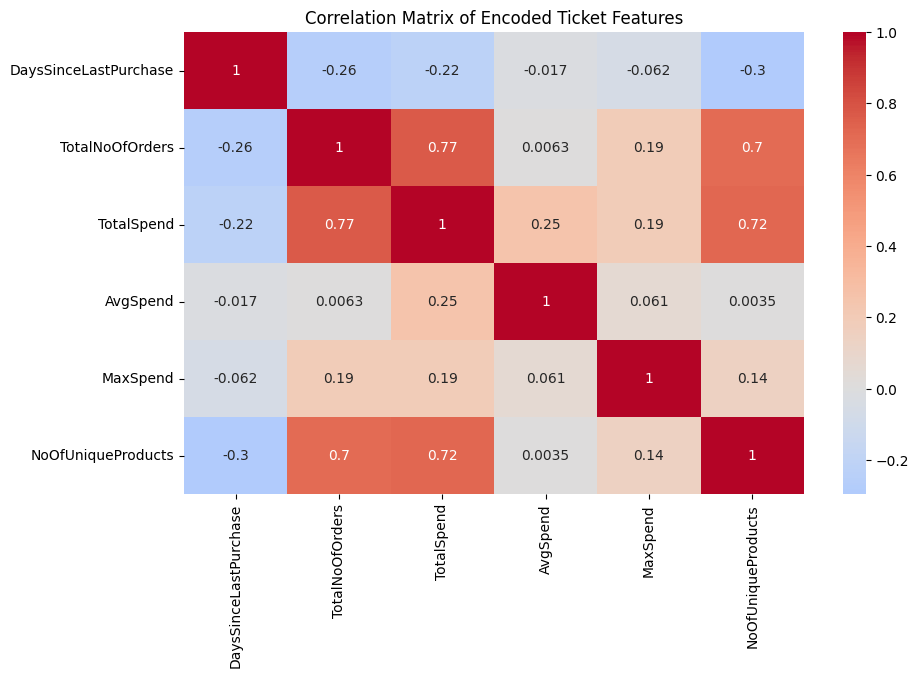

In [85]:
# Importing visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Creating a correlation matrix for the encoded features
corr_matrix = df_encoded.corr()

# Correlation heatmap visualisation
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Matrix of Encoded Ticket Features")
plt.show()


Looking at the heatmap above, we can draw the following conclusions:

1. Frequency (TotalNoOfOrders), Spend (TotalSpend) and Product Diveristy (NoOfUniqueProducts) are all strongly correlated with each other. Each of these combinations has a correlation of 0.7+. This shows us that customers that order more frequently tend to spend more money and buy a greater variety of products. This signifies these customers as our high-value customers, in business terms, these are the customers we need to ensure we continue to satisfy and maintain frequent and recurring revenue. They represent the biggest impact to the business if they start to churn. In data science terms, this also tells us that these features are somewhat redundant, supporting the decision to carry out PCA in the next step.
2. Recency is negatively correlated with orders (-0.26), spend (-0.22) and products (-0.3). This indicates that less active customers exhibit lower purchasing activity and value. This reinforces recency as a critical predictor of churn.
3. Average Spend and Max Spend are more independent. These attributes are not strongly correlated with any other, indicating that customers with the same average spend may be entirely unique (e.g one makes many smaller purchases - unlikely to churn, another makes only one large purchase - high churn probability) showing us that one large purchase does not produce loyalty and that the average spend metric is not redundant information and should be retained.

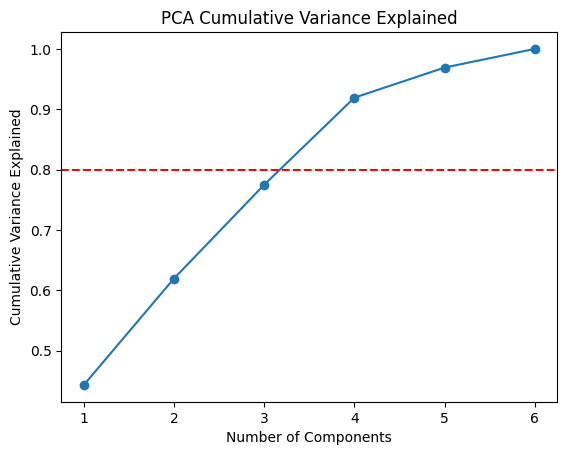

In [ ]:
# Import libraries for PCA
from sklearn.decomposition import PCA

# Performing PCA on the scaled data
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Extracting the explained variance ratio for each principal component
explained_variance = pca.explained_variance_ratio_

# Creating a DataFrame to display the variance explained by each principal component
variance_df = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Variance Explained": explained_variance,
    "Cumulative Variance": np.cumsum(explained_variance)
})

# Visualising the cumulative variance explained by the principal components to determine how many components to retain
plt.plot(variance_df["Component"], variance_df["Cumulative Variance"], marker="o")
plt.axhline(0.8, linestyle="--", color="red")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Cumulative Variance Explained")
plt.show()

In the graph above, there is a line set at 0.8 of the Cummulative Variance Explained. 80% variance is commonly used in academia and industry, we see this in Jolliffe (2002) where the author states that a 0.8 threshold allows the data to be "reasonably faithful" to the source material. Setting the value at 80% means that we retain a high level of meaningful data, without overfitting. 

This graph shows us there is no single dominant component. We see that approximately 3-4 components explains 80% of the variance, therefore the effective dimensionality of the data after PCA is lower than the raw encoded feature space, removing redundancy and making future processing more efficient.

Beyond 4 components we see dimishing returns so each new component is adding little value and is likely not worth the additional processing to include these.

Note: Literature search was enhanced using Copilot (Microsoft, 2026) to identify academic justification for the 80% threshold.

In [ ]:
# Retaining the number of principal components that explain at least 80% of the variance
n_components = variance_df[variance_df["Cumulative Variance"] <= 0.8].shape[0]
X_reduced = X_pca[:, :n_components]

In [58]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df_encoded.columns,
    index=[f"PC{i+1}" for i in range(len(pca.components_))]
)

loadings

,DaysSinceLastPurchase,TotalNoOfOrders,TotalSpend,AvgSpend,MaxSpend,NoOfUniqueProducts
PC1,-0.261272,0.544171,0.553656,0.097508,0.187784,0.533206
PC2,0.262176,-0.124180,0.149297,0.877267,0.308851,-0.169020
PC3,0.196885,0.013001,-0.105395,-0.367330,0.900957,-0.057481
PC4,0.904177,0.201700,0.194934,-0.163683,-0.235021,0.147492
PC5,0.063437,-0.599005,-0.157896,0.056000,0.048837,0.778920
PC6,-0.051731,-0.537399,0.772746,-0.236719,-0.002067,-0.235264


Explanations:

PC1: Represents overall customer engagement and value, we see this for the strong positive loadings for TotalNoOfOrders (0.54), TotalSpend (0.55) and NoOfUniqueProducts (0.53) and negative loading for DaysSinceLastPurchase (-0.26) - implying less days since the last order. This Principal Component represents active loyal customers best.

PC2: Represent customers who tend to spend a lot on average, but are newer/frequent customers. These customers should still be regarded as high value, and show that high-value doesn't always mean high frequency.

PC3: Big Spenders: These are the customers who make very large purchases (MaxSpend = 0.90), but are not return customers. This shows us that MaxSpend and TotalSpend are distinct.

PC4: Recency driven behaviour. This principal component is heavily weighted by DaysSinceLastPurchase (0.90), showing us that recency is an independent behavioural attribute. This will be key in later churn modelling.

PC5: Diversity vs frequency. PC5 separates customers who buy many unique products and those who make many repeat purchases, showing us that not all frequent buyers are diverse buyers. 

PC6: Spend without frequency. This is similar to PC2 and shows customers who spend a lot but don't order often. This is a real world example supporting Jolliffe's idea that we see dimishing returns in terms of new insights gained as the number of components increase.

## Exploratory Data Analysis (EDA)

Now that the data is prepared and scaled where appropriate, EDA needs to occur. We can reference John Tukey's 1977 book where he writes that a visual summary of the data are crucial in understanding the underlying data. By carrying out an EDA stage prior to modelling we can validate the data cleansing we have carried out as well as reveal categories for further exploration and guide modelling decisions.

#### Exploration 1: Customer Types

In this first Exploration we will look the the division of the customers in the dataset to understand whether we have enough information about each customer group to form meaningful conclusions.

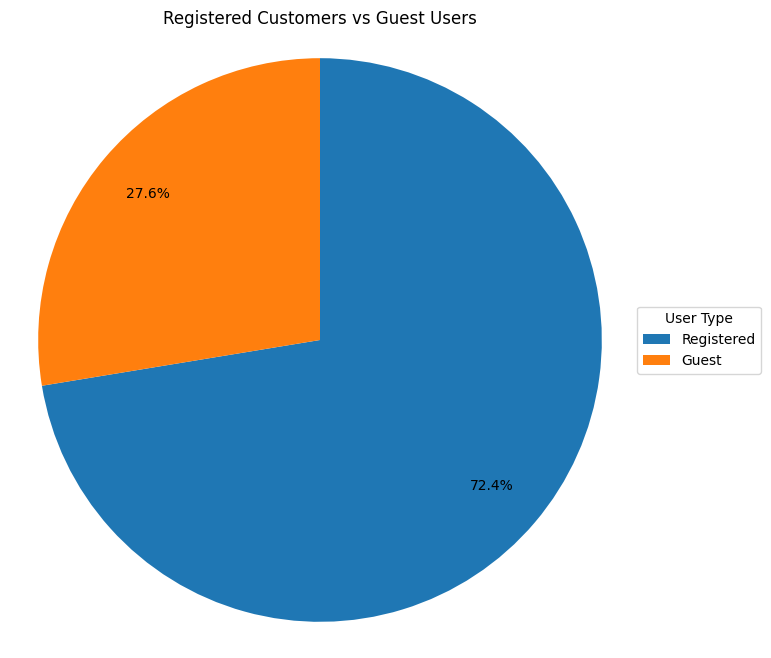

In [91]:
# Calculating counts
counts = df["CustomerTypeFlag"].value_counts()

# Generating pie chart
fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(
    counts,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.8
)

# Show chart
ax.set_title("Registered Customers vs Guest Users")
ax.legend(wedges, ["Registered", "Guest"], title="User Type", loc="center left", bbox_to_anchor=(1,0.5))
ax.axis("equal")
plt.show()

This pie chart shows us that the majority of transactions (72.4%) are associated with registered customers, indicating that most purchasing behaviour can be linked to identifiable individuals. This proves that we have enough data for customer churn modelling, however data is still being lost through guest purchases, limiting the completeness of behavioural analysis.

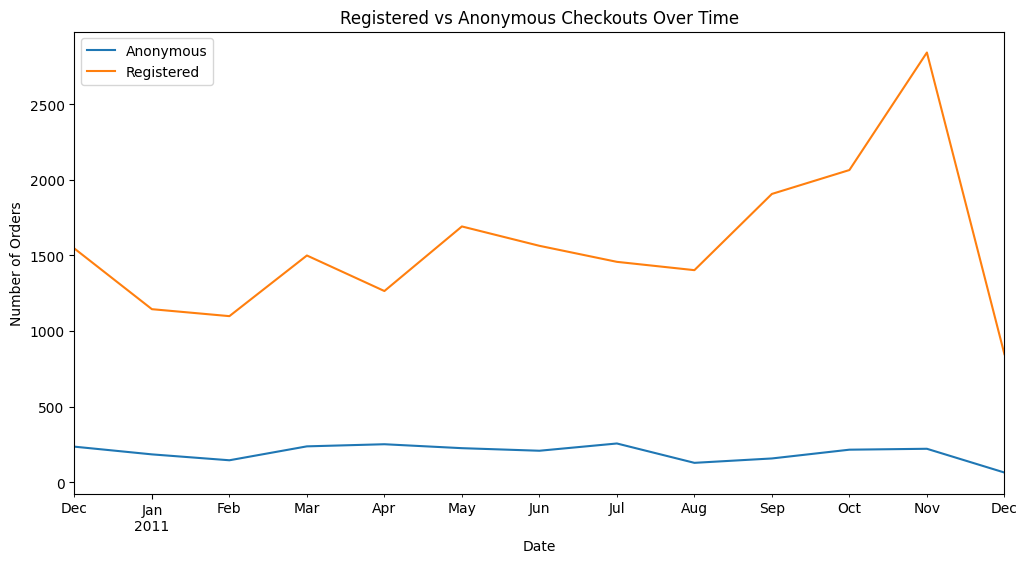

In [ ]:
# Creating a Year-Month column for grouping
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# Calculating the number of unique orders per month for registered and anonymous customers
checkout_trends = df.groupby(
    ["YearMonth", "CustomerTypeFlag"]
)["InvoiceNo"].nunique().reset_index()

# Pivoting the data to have separate columns for registered and anonymous customers
checkout_trends = checkout_trends.pivot(
    index="YearMonth",
    columns="CustomerTypeFlag",
    values="InvoiceNo"
)

# Renaming the columns for better readability
checkout_trends.columns = ["Anonymous", "Registered"]
checkout_trends.index = checkout_trends.index.to_timestamp()

# Visualising the checkout trends over time for registered and anonymous customers
checkout_trends.plot(figsize=(12,6))
plt.title("Registered vs Anonymous Checkouts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()


This line chart supports that data above showing that registered users consistently represent a larger proportion of the order base over time. December does look like a big shift in customer behaviour, however this is easily explained by the latest order date being the 9th December, showing us that the December data is currently incomplete.

In terms of general trends, we do see the number of registered customers slowing increasing per month, suggesting growth in the business or seasonality in the data, potentially previous guest users registering after a previous positive order? For the guest users, the numbers remain relatively stable month on month.

Both of these graphs support the notion that customer retention is key for future business growth and stability. Since the majority of transactions are linked to identifiable customers, it is appropriate to construct a customer-level dataset and perform churn prediction. Anonymous transactions, while present, are unlikely to significantly impact model performance due to their relatively small proportion.

#### Exploration 2: Churn Indicators

In this section we look at one of the insights derived from the PCA, specifically PC4 which showed that recency is an important independent attribite key to identifying at risk customers. 

<Axes: xlabel='DaysSinceLastPurchase', ylabel='Count'>

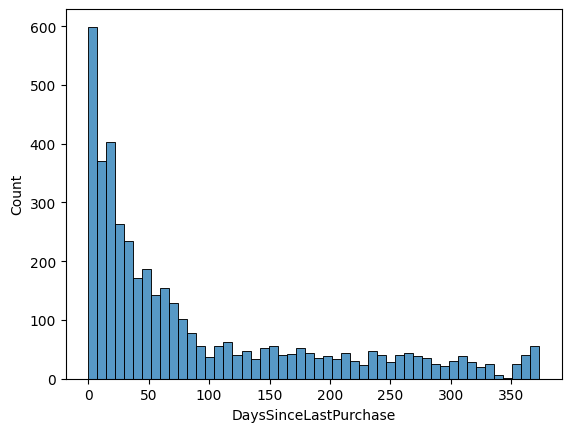

In [ ]:
# Create histogram of DaysSinceLastPurchase
sns.histplot(customer_df["DaysSinceLastPurchase"], bins=50)

This histogram is heavily right skewed showing a large concentration of customers ordering within the last 50 days, with a long tail of customers who have not purchased for some time. This demonstrates that the majority of registered customers have shopped with the company recently, and while small, we can see that customers are churning. However it is important to note that this data may not be entirely complete as it only includes roughly 1 year of data. A larger time frame would be beneficial to see if this pattern is consistent over a longer time frame. The descriptive statistics below support this, with the average recency being relatively high due to the long tail, but the median is much lower, indicating that most customers are active while a subset of customers are highly inactive. 

Industry professionals generally consider a customer churned if there is no repeat custom within 120 days. To represent this I have segmented my customers to be classed as churned if no orders have been made in 116 days (71st percentile) and as a churn risk if they have not shopped within the last 84 - 116 days (as close to 90 as I could get using percentiles).

In [62]:
customer_df['DaysSinceLastPurchase'].describe()

count    4255.000000
mean       91.545711
std       100.733073
min         0.000000
25%        16.000000
50%        49.000000
75%       144.000000
max       373.000000
Name: DaysSinceLastPurchase, dtype: float64

In [63]:
customer_df["DaysSinceLastPurchase"].quantile(0.65)

84.0

In [64]:
customer_df["DaysSinceLastPurchase"].quantile(0.71)

116.0

In [93]:
def customer_health(recency):
    """
    This function categorises customers into "Active", "Churn Risk" and "Churned" based on the number of days since their last purchase. 
    The thresholds for these categories are determined by the 65th and 71st percentiles of the "DaysSinceLastPurchase" column in the customer dataframe.

    Parameters
    -----------
    recency: int
        The number of days since the customer's last purchase

    Returns
    -------
    Customer Health: str
        The health category of the customer based on their recency

    """
    if recency <= customer_df["DaysSinceLastPurchase"].quantile(0.65):
        return "Active"
    elif recency <= customer_df["DaysSinceLastPurchase"].quantile(0.71):
        return "Churn Risk"
    else:
        return "Churned"

# Assigning a customer health category to each customer in the customer dataframe based on their recency
customer_df["CustomerHealth"] = customer_df["DaysSinceLastPurchase"].apply(customer_health)

<Axes: xlabel='TotalNoOfOrders', ylabel='TotalSpend'>

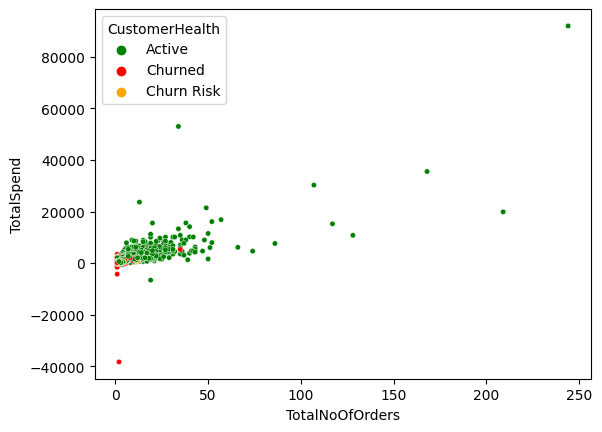

In [ ]:
# Setting the colour palette for the scatterplot
palette = {
    "Active": "green",
    "Churn Risk": "orange",
    "Churned": "red"
}

# Creating a scatterplot to visualise the relationship between the number of orders and total spend for customers, coloured by their health category
sns.scatterplot(
    data=customer_df,
    x="TotalNoOfOrders",
    y="TotalSpend",
    hue="CustomerHealth",
    s = 15,
    palette=palette
)

The graph above clearly shows a clear clustering of orders, most customers can be described as ordering <50 times with active customers generally having spent a little more money than the churn or churn risk customers, showing these customers are engaging less with the business. Once again this visualisation is limited by the time frame of this dataset, as a longer time period could paint a different picture. 

In [97]:
import plotly.express as px

fig = px.scatter_3d(
    customer_df,
    x="TotalNoOfOrders",
    y="TotalSpend",
    z="NoOfUniqueProducts",
    color="CustomerHealth",
    color_discrete_map={
        "Active": "green",
        "Churn Risk": "orange",
        "Churned": "red"
    },
    title="3D Customer Behaviour: Orders, Spend, and Product Diversity"
)

fig.show()

This multidimensional graph builds on the visualisation above by introducing an additional attribute, Number of Unique Products. The findings from this graph are clear, the insights we drew from the previous graph and PCA are validated, more orders -> more spend -> more diversity and that active customers show higher brand engagement. What this graph adds is that it shows us that these features work together to create behavioural profiles and combination of factors contributes to customer churn or retention. We also see red, amber and green clusters begin to emerge in this plot. The other point to note is that there are a few high value outliers. These customers represent a small number of highly engaged customers and are crucial to retain. A recommendation here would be to assign these accounts dedicated sales managers if budget allows to maximise their opportunity.

In [ ]:
# Create list of customers and monthly timeline
customers = df["CustomerID"].dropna().unique()

months = pd.date_range(
    df["InvoiceDate"].min(),
    df["InvoiceDate"].max(),
    freq="MS"
)

# Create a grid of customers x months
grid = pd.MultiIndex.from_product(
    [customers, months],
    names=["CustomerID", "YearMonth"]
).to_frame(index=False)

df_sorted = df.sort_values(["CustomerID", "InvoiceDate"])

# Merge grid with purchase data
merged = grid.merge(
    df_sorted[["CustomerID", "InvoiceDate"]],
    on="CustomerID",
    how="left"
)

# Get last purchase before each month
last_purchase = merged.groupby(
    ["CustomerID", "YearMonth"]
)["InvoiceDate"].max().reset_index()

# Compute recency
last_purchase["Recency"] = (
    last_purchase["YearMonth"] - last_purchase["InvoiceDate"]
).dt.days

# Get first purchase date per customer
first_purchase = df.groupby("CustomerID")["InvoiceDate"].min().reset_index()
first_purchase.columns = ["CustomerID", "FirstPurchaseDate"]

# Merge into last_purchase
last_purchase = last_purchase.merge(
    first_purchase,
    on="CustomerID",
    how="left"
)

# Remove months before first purchase
last_purchase = last_purchase[
    last_purchase["YearMonth"] >= last_purchase["FirstPurchaseDate"]
]

# Apply health segmentation
last_purchase["CustomerHealth"] = last_purchase["Recency"].apply(customer_health)


# Aggregate counts for plotting
health_counts = last_purchase.groupby(
    ["YearMonth", "CustomerHealth"]
).size().reset_index(name="Count")


# Fix missing combinations
health_counts = health_counts.pivot(
    index="YearMonth",
    columns="CustomerHealth",
    values="Count"
).fillna(0).reset_index()

health_counts = health_counts.melt(
    id_vars="YearMonth",
    var_name="CustomerHealth",
    value_name="Count"
)

# Plot interactive bar chart
fig = px.bar(
    health_counts,
    x="CustomerHealth",
    y="Count",
    color="CustomerHealth",
    animation_frame="YearMonth",
    category_orders={
        "CustomerHealth": ["Active", "Churn Risk", "Churned"]
    },
    color_discrete_map={
        "Active": "green",
        "Churn Risk": "orange",
        "Churned": "red"
    },
    title="Customer Health Over Time (Dynamic Churn Model)"
)

fig.update_layout(
    yaxis=dict(range=[0, health_counts["Count"].max()])
)

fig.show()

The interactive dashboard above shows a clear picture of how customer classifications trend over time. 

The first few months represent all customers as active, this is because we are working with a lack of historical data. At this time, churn risk and churned customers could exist, but we do not have the records to represent them.

From March onwards we see churn risk customers appearing with churned customers following swiftly after. In the last few months we see the numbers begin to settle for each column with little variation this month. Once again, this visualisation supports the business importance of collecting useable data. As time goes on, the insights generated by this workbook would only grow stronger compared to its current limited form.

This graph clearly demonstrates that churn is not a static process, but rather a dynamic one driven by customer experience. This demonstrates that the business has time to recover and retain customers, but that time is finite, especially in crowded markets. 

All of the graphs created in this section demonstrate that recency is most likely the strongest churn indicator and continual engagement with the business is what is driving recurring revenue, however it is important to note that behaviour does change over time, reinforcing the notion that customer experience and product quality must remain high to retain customers.

#### Exploration 3: 

Earlier EDA has shown that spend is an inmportant customer characteristic. This visualisation explores whether patterns emerge within customer groups due to spend.

<Axes: xlabel='TotalSpend', ylabel='Count'>

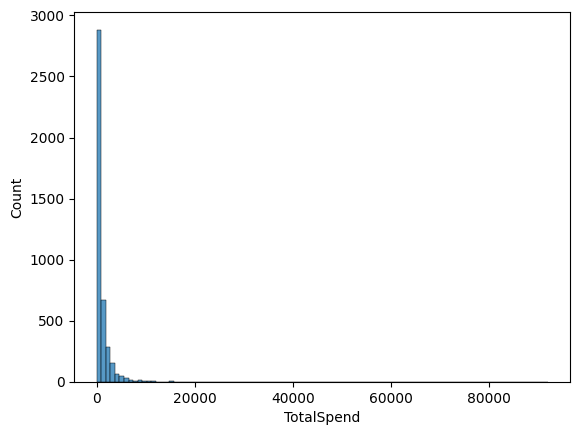

In [ ]:
sns.histplot(customer_df[customer_df["TotalSpend"] > 0]["TotalSpend"], bins=100)

This graph is heavily right-skewed, once again showing that most customers spend fairly little, however the presence of higher value spends on the axis show that there are a small number of 'outlier' customers who have spent x4 more than most customers. This supports the idea that each customer is not equally valuable but rather are 'Pareto-type' or similar where 20% of the customers represent 80% of the value.

When considering future modelling, these 'outliers' could distort models, once again proving the value of the PCA and scaling completed.

#### Exploration 4: Order Quantities

So far the EDA has focused on customer driven insights, in this final exploration, the original orders dataset is ised

<Axes: xlabel='Quantity', ylabel='Count'>

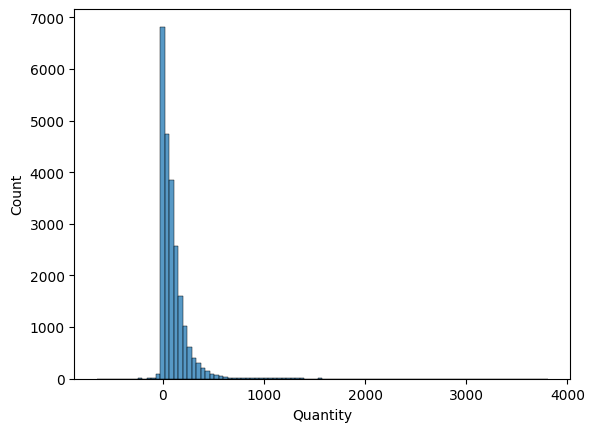

In [69]:
order_items = df.groupby("InvoiceNo")["Quantity"].sum()
sns.histplot(order_items, bins=100)

This graph mirrors the findings from earlier EDA, but rooted in product quantites. This right-skewed distribution shows us that most products are ordered in small quantites, however, bulk orders do exist. This once again supports the idea of clear customer segments based off of spend, recency and quantites. 

In [ ]:
df["IsReturn"] = df["Quantity"] < 0
product_returns = df.groupby(["Description", "IsReturn"])["Quantity"].sum().unstack()

product_returns["Returns"] = product_returns[True].abs()
product_returns["Kept"] = product_returns[False]
product_returns["ReturnRate"] = product_returns["Returns"] / (product_returns["Returns"] + product_returns["Kept"])


product_returns = product_returns[["ReturnRate"]]

top_returns = product_returns.sort_values("ReturnRate", ascending=False).head(10)


IsReturn,False,True,Returns,Kept,ReturnRate
Description,,,,,
"RUBY GLASS NECKLACE 42""",1.0,NaN,NaN,1.0,NaN
MUMMY MOUSE RED GINGHAM RIBBON,1.0,NaN,NaN,1.0,NaN
HAYNES CAMPER SHOULDER BAG,1.0,NaN,NaN,1.0,NaN
MARIE ANTOIENETT TRINKET BOX GOLD,1.0,NaN,NaN,1.0,NaN
WATERING CAN SINGLE HOOK PISTACHIO,1.0,-1.0,1.0,1.0,0.5
BLOSSOM IMAGES SCRAP BOOK SET,1.0,NaN,NaN,1.0,NaN
Found by jackie,1.0,NaN,NaN,1.0,NaN
TEA TIME BREAKFAST BASKET,1.0,-1.0,1.0,1.0,0.5
ORANGE/FUSCHIA STONES NECKLACE,1.0,NaN,NaN,1.0,NaN


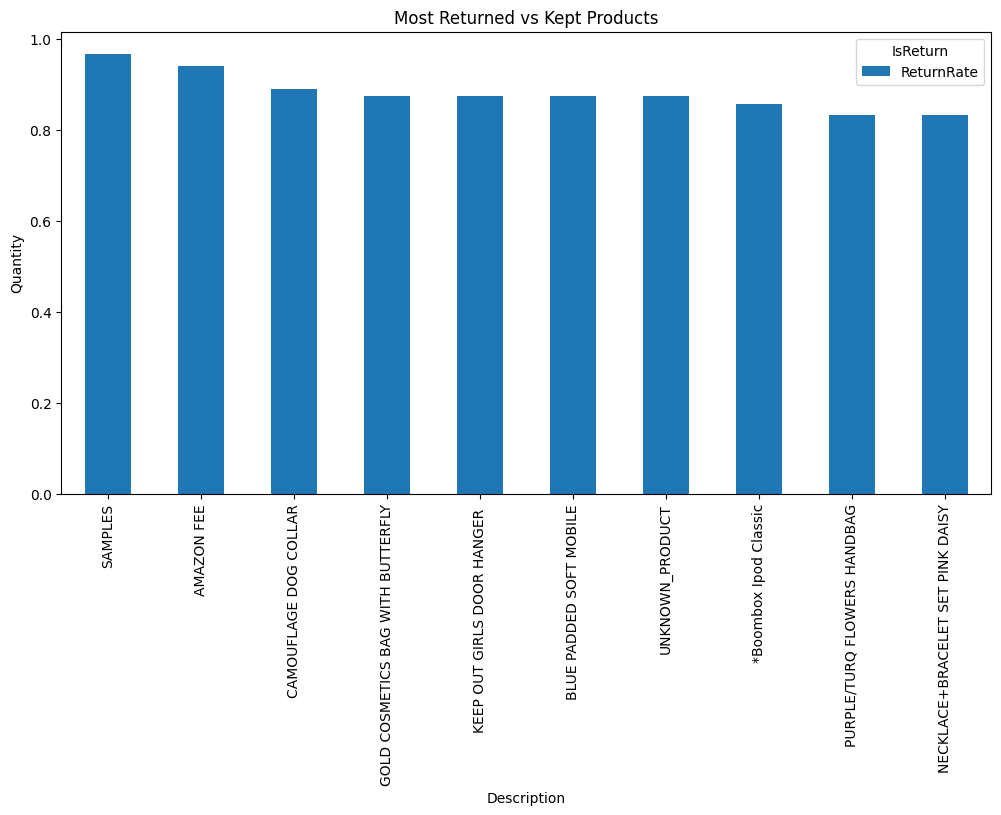

In [107]:
top_returns.plot(kind="bar", figsize=(12,6))

plt.title("Most Returned vs Kept Products")
plt.ylabel("Quantity")
plt.xticks(rotation=90)
plt.show()

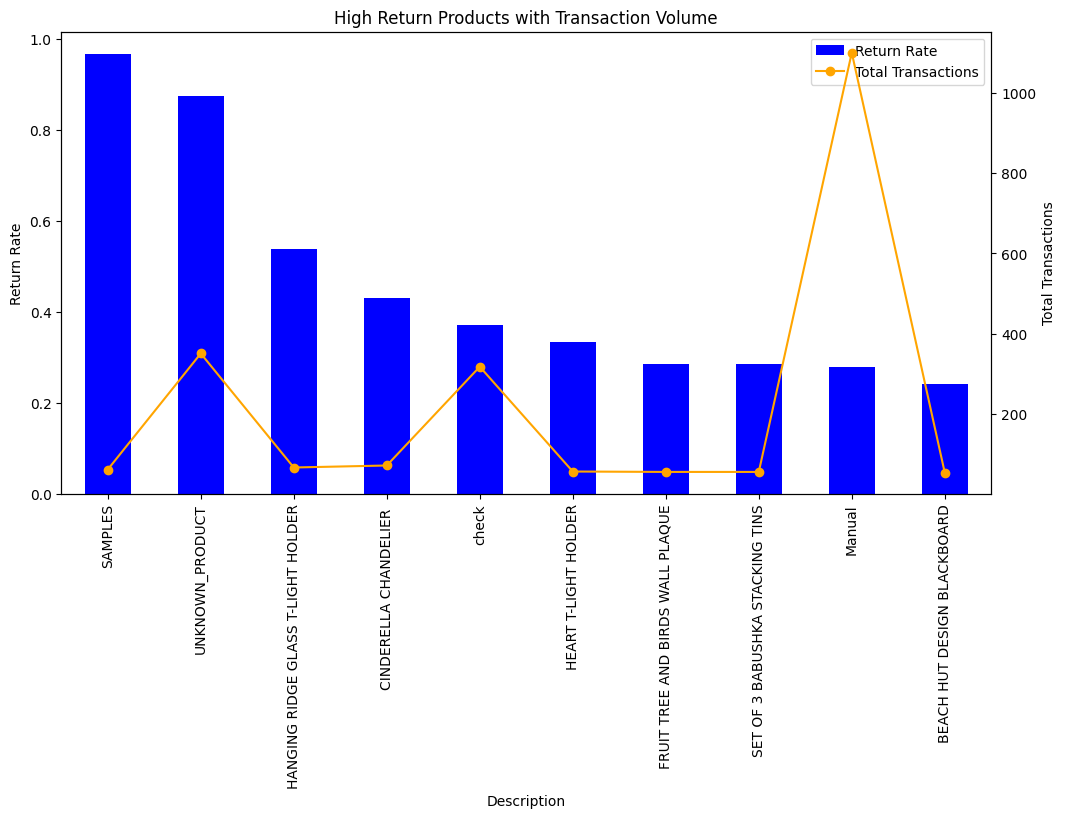

In [111]:
# Identify returns
df["IsReturn"] = df["Quantity"] < 0

# Aggregate quantities
product_returns = df.groupby(["Description", "IsReturn"])["Quantity"].sum().unstack()

# Create clean columns
product_returns["Returns"] = product_returns[True].abs()
product_returns["Kept"] = product_returns[False]

# Total volume
product_returns["TotalTransactions"] = product_returns["Returns"] + product_returns["Kept"]

# Calculate return rate
product_returns["ReturnRate"] = product_returns["Returns"] / product_returns["TotalTransactions"]

# Filter out low-volume products
product_returns = product_returns[product_returns["TotalTransactions"] > 50]

# Select top returned products
top_returns = product_returns.sort_values("ReturnRate", ascending=False).head(10)

# Plot with both return rate and volume
ax = top_returns["ReturnRate"].plot(
    kind="bar",
    color="blue",
    figsize=(12,6),
    label="Return Rate"
)

# Add secondary axis for volume
ax2 = ax.twinx()
top_returns["TotalTransactions"].plot(
    kind="line",
    marker="o",
    color="orange",
    ax=ax2,
    label="Total Transactions"
)

# Labels + formatting
ax.set_title("High Return Products with Transaction Volume")
ax.set_ylabel("Return Rate")
ax2.set_ylabel("Total Transactions")

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Legend fix
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2)

plt.show()

This graph above shows us the products that are consistently returned when more than 50 purchases are made. This suggests that they are of poor quality, do not meet expectations or a advertised misleadingly. We see disproportionate returns for UNKNOWN_PRODUCT, check and Manual products. This uncovers a deeper issue into data recording where clearly a standard for manual product descriptions has not been set and uncovers a limitation in earlier data cleansing steps.

To resolve this, these values are combined into one description which can be filtered out if needed in later analysis.

In [ ]:
non_product_labels = ["Manual", "UNKNOWN_PRODUCT", "check"]

df["Description"] = df["Description"].replace(non_product_labels, "NON_PRODUCT")

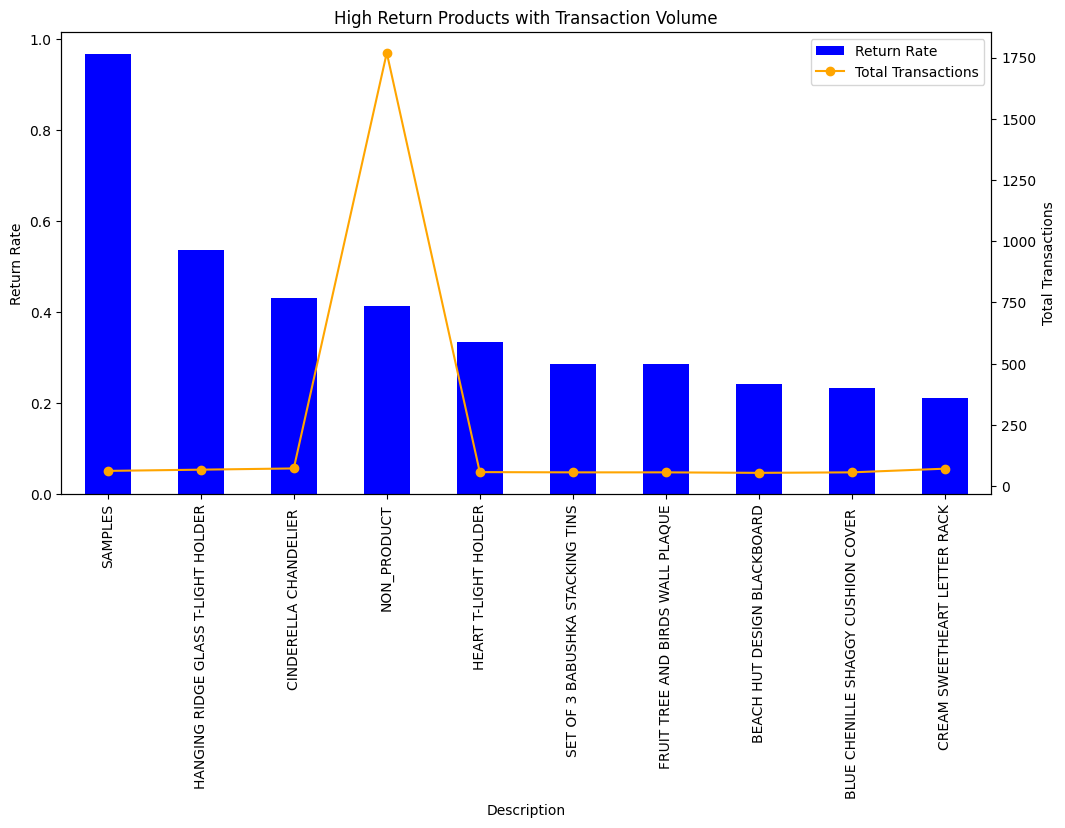

In [113]:
# Identify returns
df["IsReturn"] = df["Quantity"] < 0

# Aggregate quantities
product_returns = df.groupby(["Description", "IsReturn"])["Quantity"].sum().unstack()

# Create clean columns
product_returns["Returns"] = product_returns[True].abs()
product_returns["Kept"] = product_returns[False]

# Total volume
product_returns["TotalTransactions"] = product_returns["Returns"] + product_returns["Kept"]

# Calculate return rate
product_returns["ReturnRate"] = product_returns["Returns"] / product_returns["TotalTransactions"]

# Filter out low-volume products
product_returns = product_returns[product_returns["TotalTransactions"] > 50]

# Select top returned products
top_returns = product_returns.sort_values("ReturnRate", ascending=False).head(10)

# Plot with both return rate and volume
ax = top_returns["ReturnRate"].plot(
    kind="bar",
    color="blue",
    figsize=(12,6),
    label="Return Rate"
)

# Add secondary axis for volume
ax2 = ax.twinx()
top_returns["TotalTransactions"].plot(
    kind="line",
    marker="o",
    color="orange",
    ax=ax2,
    label="Total Transactions"
)

# Labels + formatting
ax.set_title("High Return Products with Transaction Volume")
ax.set_ylabel("Return Rate")
ax2.set_ylabel("Total Transactions")

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Legend fix
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2)

plt.show()

The earlier graph is recreated and we can 'ignore' the NON_PRODUCT category for now. Based on this graph we should look into the 3 products on the right, as at least 25% of these products are returned. The next idea to expllore is whether product returns impact churn rates, this is explored in the graph below.

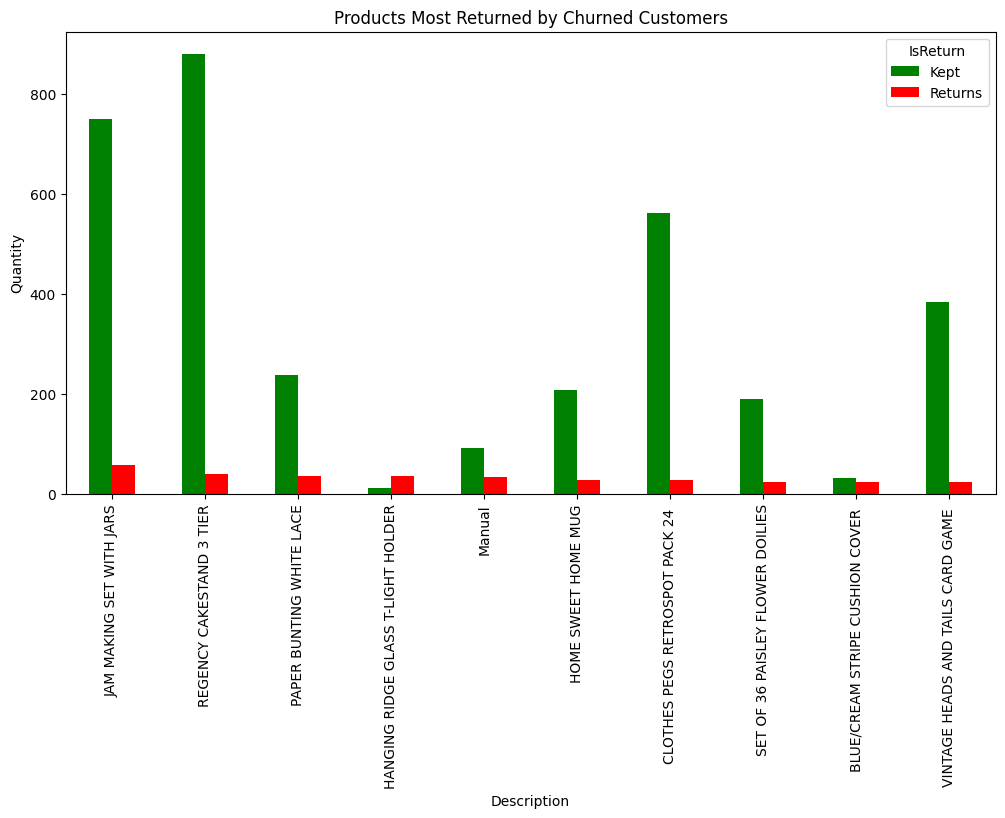

In [109]:
churned_df = df.merge(
    customer_df[["CustomerID", "CustomerHealth"]],
    on="CustomerID",
    how="left"
)

churned_df = churned_df[churned_df["CustomerHealth"] == "Churned"]

churned_products = churned_df.groupby(["Description", "IsReturn"])["Quantity"].sum().unstack()

churned_products["Returns"] = churned_products[True].abs()
churned_products["Kept"] = churned_products[False]

churned_products = churned_products[["Kept", "Returns"]]

top_churned_products = churned_products.sort_values("Returns", ascending=False).head(10)

top_churned_products.plot(kind="bar", figsize=(12,6), color=["green", "red"])

plt.title("Products Most Returned by Churned Customers")
plt.ylabel("Quantity")
plt.xticks(rotation=90)
plt.show()

This final graph shows us that churned customers frequently return certain products, potentially linking churn to a poor product experience. For example, almost all purchases of the Blue/Cream Stripe Cushion Cover were returned, potentially highlighting a severe product issue that drives customers away.

It is also important to mitigate the potential data quality question that could be raised by looking at this graph. We can see that the number of 'Hanging Ridge Tea Light Holders' bought is higher than those returned, this may be due to the fact that the customer returned the item after being considered churned, however we cannot confirm this without knowing the returns policy or exception for this return, but this idea also supports the notion that poor product experience can lead to churn, even in later customer lifecycle stages.

### Key Insights from EDA

1. Recency is likely the strongest indicator of churn
2. High-value customers tend to be high-frequency buyers
3. Customer value is highly skewed (Pareto-like distribution)
4. Product returns are linked to churn behaviour
5. Behaviour forms clusters rather than a continuum

These insights inform feature selection and support the development of a churn prediction model using behavioural features which will be created in the section below.